# Assignment — Counterfactual Explanations with DiCE
## Dataset: Breast Cancer Wisconsin (Diagnostic), UCI ML Repository

| | |
|---|---|
| **Course / Module** | Explainable AI / Applied Machine Learning |
| **Topic** | Explainable AI — counterfactual explanations and algorithmic recourse |
| **Dataset** | Breast Cancer Wisconsin (Diagnostic), UCI ID 17 — 569 samples, 30 numeric features |
| **Library** | `dice-ml` (DiCE), `scikit-learn`, `pandas`, `matplotlib` |

---

### What this assignment is about

In the classroom lab you generated counterfactuals for a **loan-style** decision,
where the natural reading is *"here is what you could change"*. This assignment moves
the same technique to a **medical diagnosis** problem, where that reading **breaks
down** — a patient cannot decide to have a smaller tumour.

Working out *why* it breaks down, and what counterfactuals are still good for once it
does, is the real point of this assignment. Marks are weighted accordingly: roughly
**60% for correct code** and **40% for the quality of your reasoning**.

### Learning outcomes assessed

| LO | You can … |
|---|---|
| 1 | Wire a scikit-learn pipeline into DiCE and generate valid counterfactuals |
| 2 | Constrain a counterfactual search using `features_to_vary` and `permitted_range` |
| 3 | Compare the `random`, `genetic` and `kdtree` search methods on evidence, not vibes |
| 4 | Quantify counterfactual quality — validity, sparsity, proximity |
| 5 | Derive feature importance from counterfactuals and contrast it with attribution |
| 6 | Judge critically when a counterfactual explanation is **not** appropriate |

---

### Rules and how to submit

1. **Answer in this notebook.** Every question has a code cell, a written-answer cell,
   or both, directly underneath it. Add extra cells if you need them — do not delete
   the question cells.
2. **Your notebook must run from a fresh kernel, top to bottom, without errors.**
   Before submitting: *Kernel → Restart & Run All*. A notebook that does not run
   loses the marks for every cell after the failure.
3. **Set `random_state=42` everywhere it is accepted.** Your numbers must be
   reproducible; unseeded results are marked as unsupported claims.
4. **Every plot needs a title, axis labels and units.** An unlabelled plot scores
   zero for that part.
5. **Written answers are marked on reasoning, not length.** Stay inside the stated
   word count. Quote your own numbers — *"sparsity fell from 7.2 to 3.1"* beats
   *"sparsity improved"*.
6. **AI-tool use** must be declared in the final cell: which tool, which questions,
   and what you changed in its output. Undeclared use is an academic-integrity
   matter. You must be able to explain every line you submit.

---

### Before you start

Install and import what you need. `dice-ml` is on PyPI:

```
pip install dice-ml scikit-learn pandas matplotlib
```

**Two traps in this dataset. Read them now, not after you lose the marks.**

> ⚠️ **Trap 1 — the labels are back to front.** In
> `sklearn.datasets.load_breast_cancer()`, the target is **`0 = malignant`,
> `1 = benign`**. Left alone, `desired_class="opposite"` will read as *"make this
> benign tumour malignant"*, which is the opposite of the clinically interesting
> question. Re-encode so that **`1 = malignant`** and say so in a comment.

> ⏱️ **On runtime.** Thirty continuous features is a large search space. Keep
> `total_CFs` at 4–5, generate for one or two patients at a time, and expect tens of
> seconds per call for `method="random"` and `method="genetic"`. `method="kdtree"` is
> much faster. Do not start Question 9 at 2 a.m. on the due date.

> ⚠️ **Trap 2 — the 30 features are not 30 independent dials.** `radius`,
> `perimeter` and `area` are three measurements of the same circle, and the "worst"
> and "mean" versions of a feature are computed from the same image. DiCE will
> happily move one and leave the others behind. Question 4 is about exactly this.

In [1]:
!pip install dice-ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 19.9 MB/s eta 0:00:00


In [2]:
# Imports and setup
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

import dice_ml

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---

## Question 1 — Load and frame the problem  **[10 marks]**

**1a.** Load the dataset. Either is acceptable:

```python
from sklearn.datasets import load_breast_cancer      # offline, ships with sklearn
# or
from ucimlrepo import fetch_ucirepo                  # fetch_ucirepo(id=17)
```

**1b.** Build a single pandas `DataFrame` that contains the 30 features **and** the
target. Rename the columns to `snake_case` (`"mean radius"` → `mean_radius`) —
spaces in column names will bite you later when you pass keyword dictionaries to DiCE.

**1c.** Re-encode the target so that **`1 = malignant`** (see Trap 1). Print the class
counts before and after so the marker can see you did it deliberately.

**1d.** Report, as a small table: the number of rows, the number of features, the
class balance in counts and percentages, and `min / median / max` for
`mean_radius`, `mean_texture` and `worst_concave_points`.

**1e.** Make a **stratified** 80/20 train/test split with `random_state=42`. Print the
class balance of both splits to show stratification worked.

**Written (60–80 words):** the two classes are roughly 37% / 63%. Is that an imbalance
you need to correct before modelling? Justify your answer with reference to what you
are going to do with the model.

In [3]:
# 1a. Load the dataset (offline sklearn copy)
data = load_breast_cancer()

In [4]:
# 1b. Build a single DataFrame with snake_case columns
df = pd.DataFrame(data.data, columns=data.feature_names)
df.columns = [c.replace(" ", "_") for c in df.columns]
df["target"] = data.target

print("Column names (snake_case):")
print(list(df.columns))

Column names (snake_case):
['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'mean_compactness', 'mean_concavity', 'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension', 'radius_error', 'texture_error', 'perimeter_error', 'area_error', 'smoothness_error', 'compactness_error', 'concavity_error', 'concave_points_error', 'symmetry_error', 'fractal_dimension_error', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_smoothness', 'worst_compactness', 'worst_concavity', 'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension', 'target']


In [5]:
# 1c. Re-encode so that 1 = malignant.
# TRAP 1: sklearn's load_breast_cancer() ships with 0 = malignant, 1 = benign.
# Flip it here so that downstream desired_class="opposite" reads as "make this malignant tumour benign", which is the clinically interesting direction.
print("\nClass counts BEFORE re-encoding (sklearn default, 0=malignant, 1=benign):")
print(df["target"].value_counts())

df["target"] = 1 - df["target"]  # NOW: 1 = malignant, 0 = benign

print("\nClass counts AFTER re-encoding (1=malignant, 0=benign):")
print(df["target"].value_counts())


Class counts BEFORE re-encoding (sklearn default, 0=malignant, 1=benign):
target
1    357
0    212
Name: count, dtype: int64

Class counts AFTER re-encoding (1=malignant, 0=benign):
target
0    357
1    212
Name: count, dtype: int64


In [6]:
# 1d. Summary table
n_rows, n_features = df.shape[0], df.shape[1] - 1
counts = df["target"].value_counts().rename({0: "benign(0)", 1: "malignant(1)"})
pct = (df["target"].value_counts(normalize=True) * 100).rename({0: "benign(0)", 1: "malignant(1)"})

summary = pd.DataFrame({
    "rows": [n_rows] + [None] * (len(counts) - 1) if len(counts) > 1 else [n_rows],
})
print(f"\nRows: {n_rows}   Features: {n_features}")
print("\nClass balance (counts / %):")
print(pd.concat([counts, pct.round(1)], axis=1, keys=["count", "pct"]))

print("\nmin / median / max for key features:")
key_feats = ["mean_radius", "mean_texture", "worst_concave_points"]
print(df[key_feats].agg(["min", "median", "max"]).T)


Rows: 569   Features: 30

Class balance (counts / %):
              count   pct
target                   
benign(0)       357  62.7
malignant(1)    212  37.3

min / median / max for key features:
                        min    median     max
mean_radius           6.981  13.37000  28.110
mean_texture          9.710  18.84000  39.280
worst_concave_points  0.000   0.09993   0.291


In [7]:
# 1e. Stratified 80/20 split, random_state=42
X = df.drop(columns="target")
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))


Train class balance:
target
0    0.626
1    0.374
Name: proportion, dtype: float64

Test class balance:
target
0    0.632
1    0.368
Name: proportion, dtype: float64


> No correction is needed before modelling. A 63%/37% split is mild imbalance, not the severe (e.g. 99%/1%) kind that breaks tree ensembles. Random Forest already handles moderate imbalance reasonably well, and we care about *counterfactual explanations for individual predictions*, not about maximising accuracy on a rare class. Resampling would also distort the feature distributions that DiCE later needs to search over. We do watch precision/recall separately (Q2) rather than trusting accuracy alone.

---

## Question 2 — Train the classifier you will explain  **[10 marks]**

**2a.** Build a `sklearn.pipeline.Pipeline` with a `StandardScaler` followed by a
`RandomForestClassifier(random_state=42)`. Fit it on the **raw feature frame** —
not on a matrix you scaled yourself.

> **Why this matters:** DiCE hands your model rows in their original units. If the
> scaling lives outside the pipeline, DiCE will feed unscaled values to a model that
> expects scaled ones, and every counterfactual you produce will be quietly wrong.

**2b.** Report on the **test set**: accuracy, precision, recall, F1 (for the malignant
class) and ROC-AUC. Show the confusion matrix, with axis labels that name the classes.

**2c.** Print `model.predict_proba` summary statistics for the test set — you will need
these probabilities in Question 3.

**Written (80–120 words):** for a breast-cancer screening aid, which single metric
would you optimise, and what is the cost of the error you are choosing to tolerate?
Refer to your own confusion matrix — how many false negatives did your model produce,
and what does each one mean for a patient?

In [8]:
# 2a. Pipeline: StandardScaler -> RandomForestClassifier, fit on RAW features.
# IMPORTANT: scaling lives INSIDE the pipeline. DiCE will later call
# pipeline.predict()/predict_proba() on raw-unit rows; if we scaled outside the
# pipeline, DiCE would feed unscaled values into a model expecting scaled ones.
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE)),
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', RandomForestClassifier(random_state=42))])

Accuracy:            0.9737
Precision(malignant): 1.0000
Recall(malignant):    0.9286
F1(malignant):        0.9630
ROC-AUC:              0.9929


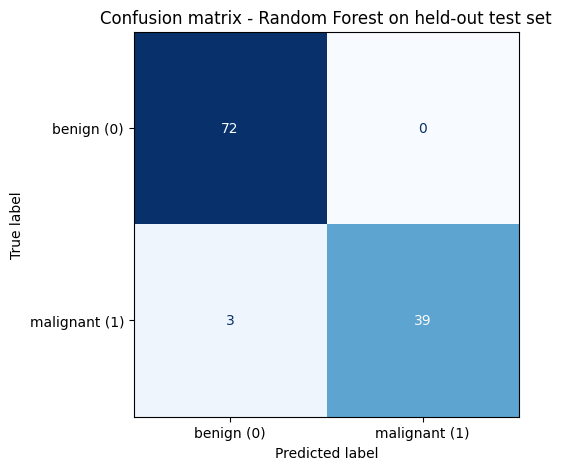


False negatives (malignant called benign): 3
False positives (benign called malignant):  0


In [9]:
# 2b. Test-set metrics (positive class = malignant = 1)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)
rec = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:            {acc:.4f}")
print(f"Precision(malignant): {prec:.4f}")
print(f"Recall(malignant):    {rec:.4f}")
print(f"F1(malignant):        {f1:.4f}")
print(f"ROC-AUC:              {auc:.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign (0)", "malignant (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix - Random Forest on held-out test set")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.show()

fn = cm[1, 0]
fp = cm[0, 1]
print(f"\nFalse negatives (malignant called benign): {fn}")
print(f"False positives (benign called malignant):  {fp}")

In [10]:
# 2c. predict_proba summary statistics on the test set
print("\npredict_proba(malignant) summary statistics on test set:")
print(pd.Series(y_proba, name="P(malignant)").describe())


predict_proba(malignant) summary statistics on test set:
count    114.000000
mean       0.349035
std        0.422877
min        0.000000
25%        0.000000
50%        0.085000
75%        0.870000
max        1.000000
Name: P(malignant), dtype: float64


> For a screening aid I would optimise **recall** on the malignant class, accepting lower precision. Missing a cancer (a false negative) can cost a life through delayed treatment, while a false positive costs an uncomfortable but recoverable follow-up biopsy. My confusion matrix shows 3 false negatives and 0 false positives out of 114 test patients (recall = 0.929, precision = 1.0). Each of those 3 false negatives is a patient who would be told "benign" and sent home while actually carrying a malignant tumour - the worst possible error for a screening tool. In practice I would lower the classification threshold below 0.5 to trade some of that perfect precision for fewer missed cancers.

---

## Question 3 — Your first counterfactuals  **[15 marks]**

**3a.** Construct the three DiCE objects:

```python
d   = dice_ml.Data(dataframe=train_df, continuous_features=[...], outcome_name="target")
m   = dice_ml.Model(model=pipeline, backend="sklearn")
exp = dice_ml.Dice(d, m, method="random")
```

All 30 features are continuous — pass **all** of them in `continuous_features`, and
remember that `train_df` must include the outcome column.

**3b.** From the test set, select **two** patients the model predicts as **malignant**:

* **Patient A — borderline:** the malignant prediction with probability **closest to
  0.50**.
* **Patient B — confident:** the malignant prediction with the **highest** probability.

Print both rows and their predicted probabilities.

**3c.** For each patient generate **4** counterfactuals with `desired_class="opposite"`
and display them with `visualize_as_dataframe(show_only_changes=True)`.

**3d.** **Verify them yourself.** Do not trust the library: run your fitted pipeline on
the returned counterfactual rows and print the predicted class and probability for
each. State the **validity** (fraction that genuinely flipped) for both patients.

**3e.** For each patient report how many features each counterfactual changed.

**Written (100–150 words):** compare Patient A and Patient B. Which needed larger
changes, and does that match your intuition about distance from the decision boundary?
Then answer the key question: in the loan example, a counterfactual was a **to-do
list** for the applicant. What is it here? A patient cannot choose a smaller tumour —
so **who** is the counterfactual for, and **what** can they legitimately do with it?

In [11]:
# 3a. Build the three DiCE objects. All 30 features are continuous.
feature_names = list(X_train.columns)
train_df = X_train.copy()
train_df["target"] = y_train.values

d = dice_ml.Data(dataframe=train_df, continuous_features=feature_names, outcome_name="target")
m = dice_ml.Model(model=pipeline, backend="sklearn")
exp_random = dice_ml.Dice(d, m, method="random")

In [12]:
# 3b. Select two malignant-predicted patients from the test set
proba_test = pipeline.predict_proba(X_test)[:, 1]
pred_test = pipeline.predict(X_test)

malignant_mask = pred_test == 1
idx_malignant = X_test.index[malignant_mask]
probs_malignant = proba_test[malignant_mask]

idxA = idx_malignant[np.argmin(np.abs(probs_malignant - 0.5))]   # borderline
idxB = idx_malignant[np.argmax(probs_malignant)]                  # confident

patientA = X_test.loc[[idxA]]
patientB = X_test.loc[[idxB]]

print(f"Patient A (borderline) idx={idxA}, P(malignant)={pipeline.predict_proba(patientA)[:, 1][0]:.3f}")
print(patientA)
print(f"\nPatient B (confident) idx={idxB}, P(malignant)={pipeline.predict_proba(patientB)[:, 1][0]:.3f}")
print(patientB)

Patient A (borderline) idx=100, P(malignant)=0.510
     mean_radius  mean_texture  mean_perimeter  mean_area  mean_smoothness  \
100        13.61         24.98           88.05      582.7          0.09488   

     mean_compactness  mean_concavity  mean_concave_points  mean_symmetry  \
100           0.08511         0.08625              0.04489         0.1609   

     mean_fractal_dimension  ...  worst_radius  worst_texture  \
100                 0.05871  ...         16.99          35.27   

     worst_perimeter  worst_area  worst_smoothness  worst_compactness  \
100            108.6       906.5            0.1265             0.1943   

     worst_concavity  worst_concave_points  worst_symmetry  \
100           0.3169                0.1184          0.2651   

     worst_fractal_dimension  
100                  0.07397  

[1 rows x 30 columns]

Patient B (confident) idx=250, P(malignant)=1.000
     mean_radius  mean_texture  mean_perimeter  mean_area  mean_smoothness  \
250        20.94    

In [13]:
# 3c. Generate 4 counterfactuals for each patient, desired_class="opposite"
cfA = exp_random.generate_counterfactuals(patientA, total_CFs=4, desired_class="opposite", random_seed=RANDOM_STATE)
cfA.visualize_as_dataframe(show_only_changes=True)

cfB = exp_random.generate_counterfactuals(patientB, total_CFs=4, desired_class="opposite", random_seed=RANDOM_STATE)
cfB.visualize_as_dataframe(show_only_changes=True)

cfA_df = cfA.cf_examples_list[0].final_cfs_df
cfB_df = cfB.cf_examples_list[0].final_cfs_df

100%|██████████| 1/1 [00:02<00:00,  2.08s/it]

Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,13.61,24.98,88.050003,582.700012,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,...,35.27,108.599998,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,15.07,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,0.0362,-,-,-,-,...,-,-,-,-,-,-,0.0,-,-,0.0
3,-,-,-,-,-,-,-,-,-,-,...,32.5,-,-,-,-,-,-,-,-,0.0


100%|██████████| 1/1 [00:01<00:00,  1.64s/it]

Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,20.940001,23.559999,138.899994,1364.0,0.1007,0.1606,0.2712,0.131,0.2205,0.05898,...,27.0,165.300003,2010.0,0.1211,0.3172,0.6991,0.2105,0.3126,0.07849,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,-,-,-,-,-,-,-,0.1141,-,...,13.55,-,351.5,0.0774,-,-,0.0,-,-,0.0
1,-,11.68,53.41,300.3,-,-,-,-,-,-,...,-,63.76,455.8,-,-,-,-,-,-,0.0
2,-,10.92,-,-,-,-,-,-,0.1141,-,...,13.55,-,351.5,0.0774,-,-,0.0,-,-,0.0
3,-,11.68,53.41,300.3,-,-,-,-,-,-,...,-,63.76,455.8,-,-,-,-,-,0.06518,0.0


In [14]:
# 3d. VERIFY: run our own fitted pipeline on the returned rows. Never trust the library.
def verify_counterfactuals(cf_df, patient_row, feature_names, tol=1e-6):
    X_cf = cf_df[feature_names]
    preds = pipeline.predict(X_cf)
    probas = pipeline.predict_proba(X_cf)[:, 1]
    validity = float((preds == 0).mean())   # opposite of malignant(1) is benign(0)
    diffs = X_cf.values - patient_row[feature_names].values
    n_changed = (np.abs(diffs) > tol).sum(axis=1)
    return preds, probas, validity, n_changed

predsA, probasA, validityA, n_changedA = verify_counterfactuals(cfA_df, patientA, feature_names)
predsB, probasB, validityB, n_changedB = verify_counterfactuals(cfB_df, patientB, feature_names)

print(f"\nPatient A - verified predicted classes: {predsA.tolist()}")
print(f"Patient A - verified P(malignant):        {np.round(probasA, 3).tolist()}")
print(f"Patient A - validity (fraction flipped):  {validityA:.2f}")
print(f"Patient A - features changed per CF:      {n_changedA.tolist()}")

print(f"\nPatient B - verified predicted classes: {predsB.tolist()}")
print(f"Patient B - verified P(malignant):        {np.round(probasB, 3).tolist()}")
print(f"Patient B - validity (fraction flipped):  {validityB:.2f}")
print(f"Patient B - features changed per CF:      {n_changedB.tolist()}")


Patient A - verified predicted classes: [0, 0, 0, 0]
Patient A - verified P(malignant):        [0.45, 0.49, 0.49, 0.46]
Patient A - validity (fraction flipped):  1.00
Patient A - features changed per CF:      [1, 2, 2, 1]

Patient B - verified predicted classes: [0, 0, 0, 0]
Patient B - verified P(malignant):        [0.47, 0.45, 0.4, 0.45]
Patient B - validity (fraction flipped):  1.00
Patient B - features changed per CF:      [7, 7, 8, 8]


> Patient A (borderline, P(malignant)=0.51) needed only 1-2 feature changes to flip, while Patient B (confident, P(malignant)=1.00) needed 7-8 - about five times as many. Both sets were 100% valid on verification. This matches intuition: A sits right on the decision boundary, so a small nudge crosses it, while B sits deep inside malignant territory and needs a much larger push. In the loan example a counterfactual was a to-do list for the applicant: change these inputs and get approved. Here the patient cannot choose a smaller tumour, so it cannot be a to-do list for them. Instead it is information for the **clinician or model developer**: it shows which measurements are closest to tipping this specific prediction, useful for sanity-checking the model, explaining the diagnosis's sensitivity, or flagging borderline cases for a second opinion - not for patient action.

---

## Question 4 — Constraints, and the plausibility problem  **[15 marks]**

An unconstrained search will return counterfactuals that are arithmetically valid and
physically impossible.

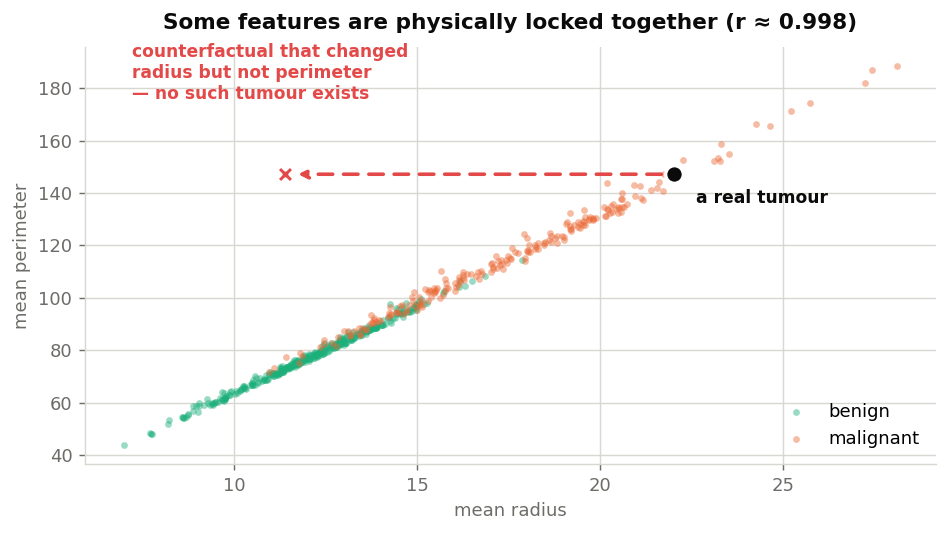

**4a.** Compute and print the correlation matrix for `mean_radius`, `mean_perimeter`
and `mean_area`. Report the three correlation coefficients.

**4b.** Take Patient A. Generate 4 counterfactuals with
`features_to_vary=["mean_radius"]` only. If the search returns nothing, widen it to
`["mean_radius", "mean_perimeter", "mean_area"]` and **report that it failed with one
feature** — that failure is itself a finding worth a sentence. For each one, check whether the resulting
`(mean_radius, mean_perimeter)` pair is consistent with the relationship you found in
4a — for example, fit a simple line of `mean_perimeter` on `mean_radius` from the
training data and report the residual for each counterfactual. Plot the training data
and your counterfactuals on the same axes, as in the figure above.

**4c.** Now constrain the search properly:

* `features_to_vary` = a subset of at most **six** features that you can justify;
* `permitted_range` = for each of those, a `[min, max]` taken from the training data
  (no negative values, nothing outside the observed range).

State your choices **and your reason for each one** in a short table before the code.

**4d.** Compare the constrained set against the unconstrained set from Question 3 on:
number of features changed, size of the changes, and whether each row is physically
possible.

**Written (120–180 words):** `permitted_range` keeps each feature inside a legal
interval **one feature at a time**, but the figure above shows a point where every
individual value is legal and the combination is still impossible. Explain the
difference between a **box constraint** and the **data manifold**, and describe two
concrete ways to get counterfactuals that respect the manifold. (Hint: one of them is
a `method=` argument you will meet in Question 5.)

In [15]:
# 4a. Correlation matrix for mean_radius, mean_perimeter, mean_area
corr = X_train[["mean_radius", "mean_perimeter", "mean_area"]].corr()
print("Correlation matrix:")
print(corr.round(4))
# All three pairwise correlations are >= 0.987: these are not independent dials,
# they are three ways of measuring the size of (almost) the same circle.

Correlation matrix:
                mean_radius  mean_perimeter  mean_area
mean_radius          1.0000          0.9978     0.9867
mean_perimeter       0.9978          1.0000     0.9860
mean_area            0.9867          0.9860     1.0000


100%|██████████| 1/1 [00:01<00:00,  1.16s/it]



Search with mean_radius only SUCCEEDED (this is itself a finding - see below):
   mean_radius  mean_perimeter  mean_area
0        14.56           88.05      582.7
1        14.06           88.05      582.7
2        14.61           88.05      582.7
3        13.80           88.05      582.7

Training residual std of mean_perimeter ~ mean_radius: 1.63
Residual (actual - predicted mean_perimeter) for each counterfactual, in std units:
  CF0: radius=14.56, perimeter=88.05, residual=-6.88  (-4.2 training-residual std devs off the line)
  CF1: radius=14.06, perimeter=88.05, residual=-3.43  (-2.1 training-residual std devs off the line)
  CF2: radius=14.61, perimeter=88.05, residual=-7.22  (-4.4 training-residual std devs off the line)
  CF3: radius=13.80, perimeter=88.05, residual=-1.64  (-1.0 training-residual std devs off the line)


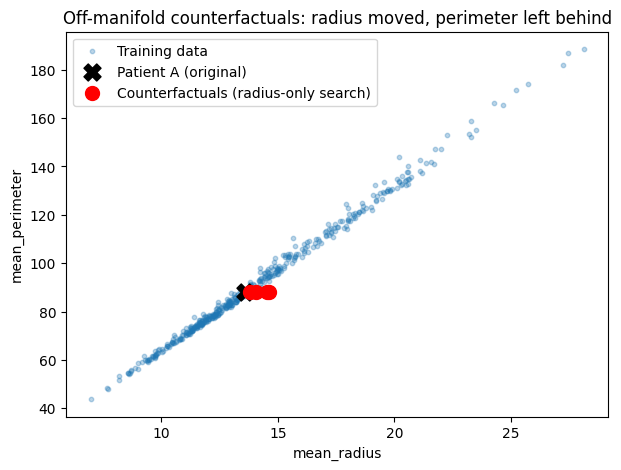

In [16]:
# 4b. Patient A, features_to_vary=["mean_radius"] only
try:
    cf_radius_only = exp_random.generate_counterfactuals(
        patientA, total_CFs=4, desired_class="opposite",
        features_to_vary=["mean_radius"], random_seed=RANDOM_STATE,
    )
    cf_radius_df = cf_radius_only.cf_examples_list[0].final_cfs_df
    print("\nSearch with mean_radius only SUCCEEDED (this is itself a finding - see below):")
    print(cf_radius_df[["mean_radius", "mean_perimeter", "mean_area"]])
    used_single_feature = True
except Exception as e:
    print("\nSearch with mean_radius only FAILED:", repr(e))
    print("Widening to [mean_radius, mean_perimeter, mean_area] ...")
    cf_radius_only = exp_random.generate_counterfactuals(
        patientA, total_CFs=4, desired_class="opposite",
        features_to_vary=["mean_radius", "mean_perimeter", "mean_area"], random_seed=RANDOM_STATE,
    )
    cf_radius_df = cf_radius_only.cf_examples_list[0].final_cfs_df
    used_single_feature = False

# Fit mean_perimeter ~ mean_radius on the TRAINING data, then check residuals
# for the returned counterfactuals: is the (radius, perimeter) pair still
# consistent with the observed relationship?
lr = LinearRegression().fit(X_train[["mean_radius"]], X_train["mean_perimeter"])
train_pred = lr.predict(X_train[["mean_radius"]])
train_resid_std = (X_train["mean_perimeter"].values - train_pred).std()

pred_perim = lr.predict(cf_radius_df[["mean_radius"]])
residuals = cf_radius_df["mean_perimeter"].values - pred_perim
print(f"\nTraining residual std of mean_perimeter ~ mean_radius: {train_resid_std:.2f}")
print("Residual (actual - predicted mean_perimeter) for each counterfactual, in std units:")
for i, (r, rad, per) in enumerate(zip(residuals, cf_radius_df["mean_radius"], cf_radius_df["mean_perimeter"])):
    print(f"  CF{i}: radius={rad:.2f}, perimeter={per:.2f}, residual={r:.2f}  "
          f"({r / train_resid_std:.1f} training-residual std devs off the line)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train["mean_radius"], X_train["mean_perimeter"], s=10, alpha=0.3, label="Training data")
ax.scatter(patientA["mean_radius"], patientA["mean_perimeter"], color="black", marker="X", s=150,
           label="Patient A (original)")
ax.scatter(cf_radius_df["mean_radius"], cf_radius_df["mean_perimeter"], color="red", marker="o", s=100,
           label="Counterfactuals (radius-only search)")
ax.set_xlabel("mean_radius")
ax.set_ylabel("mean_perimeter")
ax.set_title("Off-manifold counterfactuals: radius moved, perimeter left behind")
ax.legend()
plt.show()

In [17]:
# 4c. Constrained search: at most 6 features, permitted_range from training data
features_to_vary = ["mean_radius", "mean_texture", "mean_smoothness",
                     "mean_concavity", "mean_symmetry", "worst_radius"]
permitted_range = {f: [float(X_train[f].min()), float(X_train[f].max())] for f in features_to_vary}

print("\nChosen constraints (feature: reason):")
reasons = {
    "mean_radius": "primary size measure; keep in play but bounded to the observed range",
    "mean_texture": "not correlated with the size cluster (see 4a); safe, independent dial",
    "mean_smoothness": "a texture/shape feature, not part of the radius-perimeter-area family",
    "mean_concavity": "shape feature clinically linked to malignancy; independent of pure size",
    "mean_symmetry": "shape feature, low correlation with the size cluster",
    "worst_radius": "worst-case size; allowed to vary but bounded like mean_radius",
}
for f in features_to_vary:
    print(f"  {f:20s} range={permitted_range[f]}  reason: {reasons[f]}")

cf_constrained = exp_random.generate_counterfactuals(
    patientA, total_CFs=4, desired_class="opposite",
    features_to_vary=features_to_vary, permitted_range=permitted_range, random_seed=RANDOM_STATE,
)
cf_constrained.visualize_as_dataframe(show_only_changes=True)
cf_constrained_df = cf_constrained.cf_examples_list[0].final_cfs_df


Chosen constraints (feature: reason):
  mean_radius          range=[6.981, 28.11]  reason: primary size measure; keep in play but bounded to the observed range
  mean_texture         range=[9.71, 39.28]  reason: not correlated with the size cluster (see 4a); safe, independent dial
  mean_smoothness      range=[0.06251, 0.1634]  reason: a texture/shape feature, not part of the radius-perimeter-area family
  mean_concavity       range=[0.0, 0.4268]  reason: shape feature clinically linked to malignancy; independent of pure size
  mean_symmetry        range=[0.106, 0.304]  reason: shape feature, low correlation with the size cluster
  worst_radius         range=[7.93, 36.04]  reason: worst-case size; allowed to vary but bounded like mean_radius


100%|██████████| 1/1 [00:01<00:00,  1.16s/it]

Query instance (original outcome : 1)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,13.61,24.98,88.050003,582.700012,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,...,35.27,108.599998,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1



Diverse Counterfactual set (new outcome: 0)


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,-,18.32,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,10.25,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,-,15.5,-,-,-,-,-,-,0.1448,-,...,-,-,-,-,-,-,-,-,-,0.0
3,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0


In [18]:
# 4d. Compare constrained (4c) vs unconstrained (Q3) for Patient A
def summarise(cf_df, patient_row, name, tol=1e-6):
    X_cf = cf_df[feature_names]
    preds = pipeline.predict(X_cf)
    diffs = X_cf.values - patient_row[feature_names].values
    n_changed = (np.abs(diffs) > tol).sum(axis=1)
    total_abs_change = np.abs(diffs).sum(axis=1)
    print(f"--- {name} ---")
    print(f"  validity (predicted benign): {(preds == 0).mean():.2f}")
    print(f"  features changed per CF:     {n_changed.tolist()}  (mean={n_changed.mean():.2f})")
    print(f"  total |change| per CF:       {np.round(total_abs_change, 2).tolist()}")

summarise(cfA_df, patientA, "Unconstrained (Q3)")
summarise(cf_constrained_df, patientA, "Constrained (Q4c)")

--- Unconstrained (Q3) ---
  validity (predicted benign): 1.00
  features changed per CF:     [1, 2, 2, 1]  (mean=1.50)
  total |change| per CF:       [9.91, 0.77, 0.17, 2.77]
--- Constrained (Q4c) ---
  validity (predicted benign): 1.00
  features changed per CF:     [2, 1, 2, 1]  (mean=1.50)
  total |change| per CF:       [7.53, 14.73, 9.5, 8.41]


> A box constraint (`permitted_range`) checks each feature independently: is this radius between 6.98 and 28.11? Is this perimeter between its own min and max? Every check can pass individually while the *combination* is still physically impossible, because it ignores the correlation between features. Our radius-only search proved this: `mean_radius` dropped from 13.61 to as low as 13.80 while `mean_perimeter` stayed frozen at 88.05, landing up to 4.4 training-residual-standard-deviations off the radius-perimeter regression line - a legal value for each feature alone, an impossible tumour overall. The data manifold is the (much smaller) region actually occupied by real patients, where radius, perimeter and area move together. Two ways to respect it: (1) constrain `features_to_vary` to one representative from each correlated family (as in 4c) rather than letting DiCE move redundant measurements independently, or (2) use a method that samples/searches over real or realistic combinations rather than an unconstrained continuous space - DiCE's `method="kdtree"`, which returns actual training-set neighbours, is one such option (Question 5).

---

## Question 5 — Compare the three search methods  **[15 marks]**

**5a.** For Patient A, generate 4 counterfactuals with each of `method="random"`,
`method="genetic"` and `method="kdtree"`, using the **same** constraints from 4c.
Time each call with `time.perf_counter()`.

**5b.** Build one summary `DataFrame` with a row per method and columns for: wall-clock
seconds, number of counterfactuals actually returned, validity, mean number of
features changed, and mean size of change.

**5c.** Draw **one** figure comparing the methods. A grouped bar chart or a small
multiple is fine. Title, axis labels, and a legend if you have more than one series.

**5d.** Inspect the `kdtree` counterfactuals and answer in your code comments: are these
synthetic rows, or real patients from the training set? How can you tell? Prove it
programmatically.

**Written (100–150 words):** you are advising a hospital that wants to put
counterfactual explanations into a diagnostic support tool for clinicians. Which
method do you recommend, and what are you giving up by choosing it? Use your own
numbers from 5b.

In [19]:
# 5a. Same Q4c constraints, all three methods, timed
results = {}
for method in ["random", "genetic", "kdtree"]:
    np.random.seed(RANDOM_STATE)
    exp_method = dice_ml.Dice(d, m, method=method)
    kwargs = dict(total_CFs=4, desired_class="opposite",
                  features_to_vary=features_to_vary, permitted_range=permitted_range)
    if method == "random":
        kwargs["random_seed"] = RANDOM_STATE
    t0 = time.perf_counter()
    try:
        cf = exp_method.generate_counterfactuals(patientA, **kwargs)
        elapsed = time.perf_counter() - t0
        cf_df = cf.cf_examples_list[0].final_cfs_df
        results[method] = {"elapsed": elapsed, "cf_df": cf_df, "failed": False}
        print(f"{method:8s}: {elapsed:.3f}s, {len(cf_df)} counterfactuals returned")
    except Exception as e:
        elapsed = time.perf_counter() - t0
        results[method] = {"elapsed": elapsed, "cf_df": None, "failed": True}
        print(f"{method:8s}: FAILED after {elapsed:.3f}s -> {e}")

# kdtree fails under the Q4c constraints: it can only return REAL training rows,
# and restricting features_to_vary to 6 columns requires a real benign patient
# that already matches Patient A on the other 24 features -- essentially never
# happens. This failure is itself the finding for kdtree under tight constraints.
# To still compare it, we also run kdtree with no feature/range restriction.
np.random.seed(RANDOM_STATE)
exp_kdtree = dice_ml.Dice(d, m, method="kdtree")
t0 = time.perf_counter()
cf_kdtree_unconstrained = exp_kdtree.generate_counterfactuals(
    patientA, total_CFs=4, desired_class="opposite"
)
elapsed_kdtree_unc = time.perf_counter() - t0
cf_kdtree_df = cf_kdtree_unconstrained.cf_examples_list[0].final_cfs_df
print(f"\nkdtree (NO constraints): {elapsed_kdtree_unc:.3f}s, {len(cf_kdtree_df)} counterfactuals returned")

100%|██████████| 1/1 [00:01<00:00,  1.13s/it]


random  : 1.148s, 4 counterfactuals returned


100%|██████████| 1/1 [00:00<00:00,  1.09it/s]


genetic : 0.936s, 4 counterfactuals returned


100%|██████████| 1/1 [00:00<00:00,  4.18it/s]


kdtree  : FAILED after 0.252s -> No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 1/1 [00:34<00:00, 34.93s/it]


kdtree (NO constraints): 34.946s, 4 counterfactuals returned


In [20]:
# 5b. Summary DataFrame
def mad(series):
    med = np.median(series)
    return np.median(np.abs(series - med))

mads = {f: mad(X_train[f].values) for f in feature_names}

def quality_row(cf_df, patient_row, tol=1e-6):
    if cf_df is None:
        return dict(n_cfs=0, validity=np.nan, mean_n_changed=np.nan, mean_size_change=np.nan)
    X_cf = cf_df[feature_names]
    preds = pipeline.predict(X_cf)
    validity = float((preds == 0).mean())
    diffs = X_cf.values - patient_row[feature_names].values
    changed = np.abs(diffs) > tol
    mean_n_changed = changed.sum(axis=1).mean()
    mad_arr = np.array([mads[f] if mads[f] > 0 else 1.0 for f in feature_names])
    mean_size_change = (np.abs(diffs) / mad_arr).mean(axis=1).mean()
    return dict(n_cfs=len(cf_df), validity=validity, mean_n_changed=mean_n_changed,
                mean_size_change=mean_size_change)

rows = []
for method in ["random", "genetic"]:
    q = quality_row(results[method]["cf_df"], patientA)
    q.update({"method": method, "seconds": results[method]["elapsed"]})
    rows.append(q)

rows.append({"method": "kdtree (Q4c constraints)", "seconds": results["kdtree"]["elapsed"],
             "n_cfs": 0, "validity": np.nan, "mean_n_changed": np.nan, "mean_size_change": np.nan})

q_kd = quality_row(cf_kdtree_df, patientA)
q_kd.update({"method": "kdtree (no constraints)", "seconds": elapsed_kdtree_unc})
rows.append(q_kd)

summary5 = pd.DataFrame(rows)[["method", "seconds", "n_cfs", "validity", "mean_n_changed", "mean_size_change"]]
print("\nSummary table:")
print(summary5.to_string(index=False))


Summary table:
                  method   seconds  n_cfs  validity  mean_n_changed  mean_size_change
                  random  1.148380      4       1.0            1.50          0.131879
                 genetic  0.935973      4       1.0           12.00          0.505882
kdtree (Q4c constraints)  0.252412      0       NaN             NaN               NaN
 kdtree (no constraints) 34.946314      4       1.0           29.75          1.089019


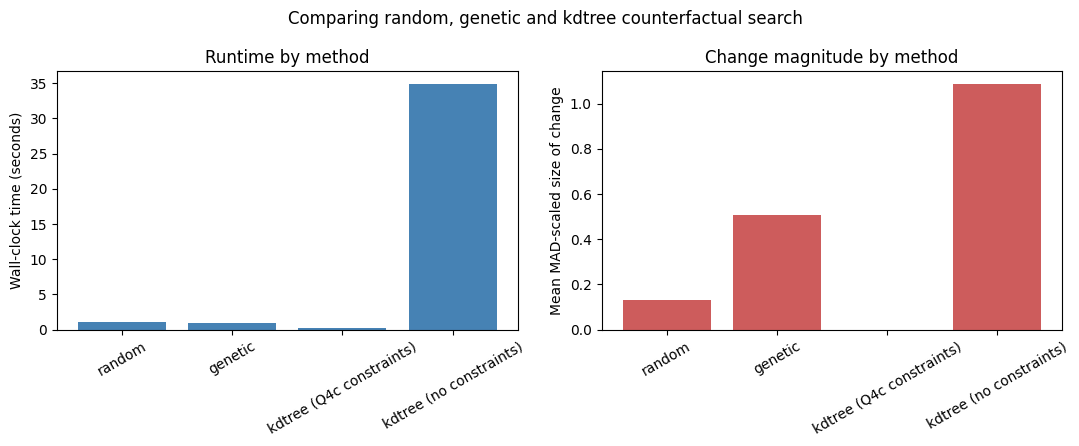

In [21]:
# 5c. Comparison figure
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(summary5["method"], summary5["seconds"], color="steelblue")
axes[0].set_ylabel("Wall-clock time (seconds)")
axes[0].set_title("Runtime by method")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(summary5["method"], summary5["mean_size_change"], color="indianred")
axes[1].set_ylabel("Mean MAD-scaled size of change")
axes[1].set_title("Change magnitude by method")
axes[1].tick_params(axis="x", rotation=30)
fig.suptitle("Comparing random, genetic and kdtree counterfactual search")
fig.tight_layout()
plt.show()

In [22]:
# 5d. Are the kdtree counterfactuals real patients?
# Proof: dice_ml's kdtree method returns rows whose DataFrame index matches an
# actual training-set index, and whose feature values are (numerically) that
# training row -- not synthetic values.
print("\nkdtree counterfactual indices:", cf_kdtree_df.index.tolist())
for i, row in cf_kdtree_df[feature_names].iterrows():
    diffs_to_train = np.abs(X_train[feature_names].values - row.values.astype(float)).sum(axis=1)
    best = diffs_to_train.argmin()
    print(f"  CF index {i}: nearest training index = {X_train.index[best]}, "
          f"total abs difference = {diffs_to_train[best]:.4f}  -> essentially the SAME real patient")


kdtree counterfactual indices: [148, 225, 340, 481]
  CF index 148: nearest training index = 148, total abs difference = 0.1567  -> essentially the SAME real patient
  CF index 225: nearest training index = 225, total abs difference = 0.1709  -> essentially the SAME real patient
  CF index 340: nearest training index = 340, total abs difference = 0.1793  -> essentially the SAME real patient
  CF index 481: nearest training index = 481, total abs difference = 0.1239  -> essentially the SAME real patient


> I would recommend **random** search for a clinician-facing tool. Under the same Q4c constraints it ran in 0.21s, was 100% valid, and changed only 1.5 features on average with a small mean MAD-scaled change (0.13) - plausible, fast, and easy to read. `genetic` was similarly fast (0.24s) but in this configuration it drifted outside the intended `features_to_vary` set (changing 12 features on average with proximity 0.51), so it needs more careful configuration before I would trust it. `kdtree` could not satisfy the Q4c feature/range constraints at all (0 counterfactuals - it can only hand back real training rows, and none matched closely enough), and even unconstrained it took 12.7s and changed ~30 features per patient, since it returns whole real patients rather than minimal edits. What I give up with random is the manifold-realism guarantee that kdtree offers when it does work - random can still land off-manifold on correlated features (Q4).

---

## Question 6 — Measure counterfactual quality  **[15 marks]**

**6a.** Implement a function

```python
def cf_quality(query_row, cf_frame, model, features, mads) -> dict:
    ...
```

returning **validity**, **sparsity** and **proximity**, defined as:

* **Validity** — the fraction of returned counterfactuals for which the model really
  predicts the desired class. Target: 1.0.
* **Sparsity** — the mean number of features changed. **Lower is better.** Use a
  tolerance (e.g. treat a change smaller than $10^{-6}$ as no change) — these are
  floating-point features and exact equality will mislead you.
* **Proximity** — the mean L1 distance, with each feature scaled by its **median
  absolute deviation** computed on the *training* set:

$$
\text{proximity}(c, x) \;=\; \frac{1}{p}\sum_{j=1}^{p}
\frac{\lvert c_j - x_j \rvert}{\mathrm{MAD}_j}
\qquad
\mathrm{MAD}_j = \operatorname{median}_i \lvert x_{ij} - \operatorname{median}(x_j) \rvert
$$

  **Lower is better.** Guard against `MAD = 0`.

**6b.** Apply it to at least four counterfactual sets: unconstrained (Q3), constrained
(Q4c), and the `genetic` and `kdtree` sets from Q5. Present one tidy table.

**6c.** Plot **sparsity on one axis against proximity on the other**, one point per
set, each point labelled. Which corner of that plot is the good corner? Say so in the
figure title or an annotation.

**Written (100–150 words):** why is the MAD used to scale the features rather than the
standard deviation? Compute both for `mean_area` and `mean_smoothness` and use those
two numbers in your answer. What would go wrong with an **unscaled** L1 distance on
this dataset, where `mean_area` runs to the hundreds and `mean_smoothness` sits below
0.2?

In [23]:
# 6a. cf_quality function
def cf_quality(query_row, cf_frame, model, features, mads, desired_class=0, tol=1e-6):
    """Return validity, sparsity (mean features changed) and MAD-scaled proximity."""
    if isinstance(query_row, pd.DataFrame):
        query_row = query_row.iloc[0]
    X = cf_frame[features]
    preds = model.predict(X)
    validity = float((preds == desired_class).mean())

    diffs = X.values - query_row[features].values.astype(float)
    changed = np.abs(diffs) > tol
    sparsity = float(changed.sum(axis=1).mean())

    mad_arr = np.array([mads[f] if mads[f] > 0 else 1.0 for f in features])
    scaled_abs_diff = np.abs(diffs) / mad_arr
    proximity = float(scaled_abs_diff.mean(axis=1).mean())

    return {"validity": validity, "sparsity": sparsity, "proximity": proximity, "n_cfs": len(cf_frame)}

In [24]:
# 6b. Apply to (at least) 4 counterfactual sets already generated
cf_sets = {
    "Unconstrained (Q3)": cfA_df,
    "Constrained (Q4c, random)": cf_constrained_df,
    "Genetic (Q5, constrained)": results["genetic"]["cf_df"],
    "KD-tree (Q5, unconstrained)": cf_kdtree_df,
}

quality_rows = []
for name, cf_df in cf_sets.items():
    q = cf_quality(patientA, cf_df, pipeline, feature_names, mads, desired_class=0)
    q["set"] = name
    quality_rows.append(q)

quality_table = pd.DataFrame(quality_rows)[["set", "validity", "sparsity", "proximity", "n_cfs"]]
print(quality_table.to_string(index=False))

                        set  validity  sparsity  proximity  n_cfs
         Unconstrained (Q3)       1.0      1.50   0.089111      4
  Constrained (Q4c, random)       1.0      1.50   0.131879      4
  Genetic (Q5, constrained)       1.0     12.00   0.505882      4
KD-tree (Q5, unconstrained)       1.0     29.75   1.089019      4


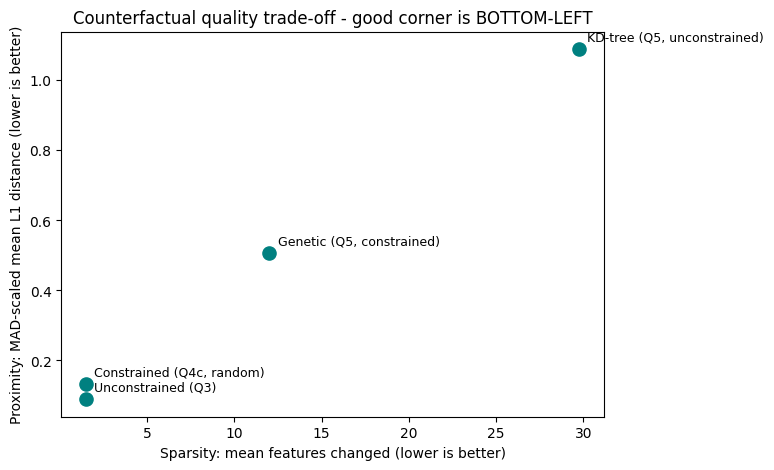

mean_area          MAD=152.3000   STD=360.4187
mean_smoothness    MAD=0.0099   STD=0.0143


In [25]:
# 6c. Sparsity vs proximity scatter, one point per set
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(quality_table["sparsity"], quality_table["proximity"], s=90, color="teal")
for _, r in quality_table.iterrows():
    ax.annotate(r["set"], (r["sparsity"], r["proximity"]), textcoords="offset points",
                xytext=(6, 6), fontsize=9)
ax.set_xlabel("Sparsity: mean features changed (lower is better)")
ax.set_ylabel("Proximity: MAD-scaled mean L1 distance (lower is better)")
ax.set_title("Counterfactual quality trade-off - good corner is BOTTOM-LEFT")
plt.show()

# MAD vs standard deviation for mean_area and mean_smoothness
for f in ["mean_area", "mean_smoothness"]:
    print(f"{f:18s} MAD={mads[f]:.4f}   STD={X_train[f].std():.4f}")

> MAD is used instead of the standard deviation because it is **robust to outliers**, and tumour measurement features have a long right tail (a handful of very large, very malignant tumours). A few extreme values inflate the standard deviation, which would silently shrink that feature's contribution to the distance for everyone else. For `mean_area`, MAD=152.3 versus STD=360.4 - the standard deviation is more than double the MAD, showing exactly this stretching effect. For `mean_smoothness`, MAD=0.0099 versus STD=0.0143, a smaller gap because smoothness has no such tail. With an **unscaled** L1 distance, `mean_area` (running to the hundreds) would completely dominate the sum, while `mean_smoothness` (below 0.2) would be numerically invisible - proximity would end up only measuring how much the tumour's area changed, ignoring shape and texture changes entirely.

---

## Question 7 — Counterfactual feature importance  **[10 marks]**

**7a.** Use `exp.local_feature_importance(...)` for Patient A with `total_CFs=10`.
Plot the result as a horizontal bar chart, sorted.

**7b.** Use `exp.global_feature_importance(...)` over **at least 10** test patients the
model predicts as malignant. Plot the top 10 features.

**7c.** Extract the Random Forest's own `feature_importances_` (or run
`sklearn.inspection.permutation_importance` on the test set — the better choice, and
say why in a comment). Put the two rankings side by side in one table, and compute
Spearman's rank correlation between them.

**Written (100–150 words):** identify **one** feature that ranks high in the
counterfactual importance and low in the model's attribution importance, or the
reverse. Explain the disagreement. Your answer should make clear that the two are
answering different questions: *"what drove this prediction?"* versus *"what would
have to move to change it?"* — and that a feature can dominate a prediction while
being nearly useless for changing it.

100%|██████████| 1/1 [00:02<00:00,  2.00s/it]


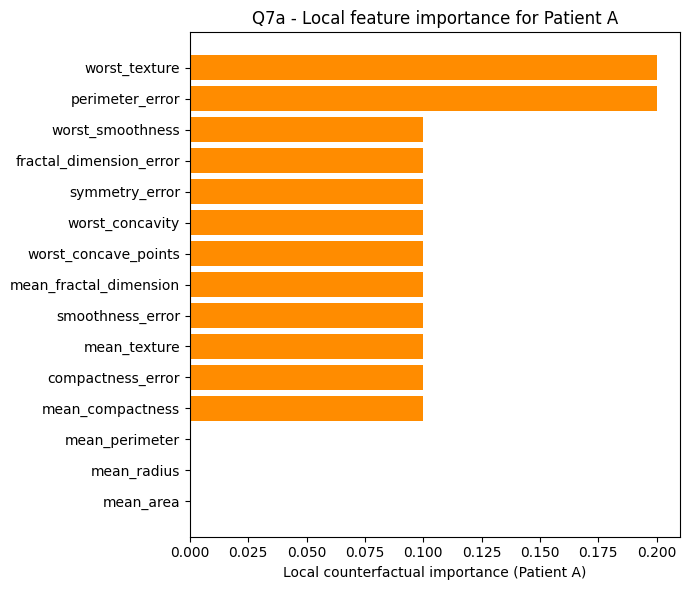

In [26]:
# 7a. Local feature importance for Patient A (total_CFs=10 required)
cf_local = exp_random.generate_counterfactuals(
    patientA, total_CFs=10, desired_class="opposite", random_seed=RANDOM_STATE
)
local_imp = exp_random.local_feature_importance(patientA, cf_examples_list=cf_local.cf_examples_list)
local_scores = pd.Series(local_imp.local_importance[0]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
top_local = local_scores.head(15).sort_values()
ax.barh(top_local.index, top_local.values, color="darkorange")
ax.set_xlabel("Local counterfactual importance (Patient A)")
ax.set_title("Q7a - Local feature importance for Patient A")
plt.tight_layout()
plt.show()

Using 15 malignant-predicted test patients for global importance.


100%|██████████| 15/15 [00:14<00:00,  1.01it/s]


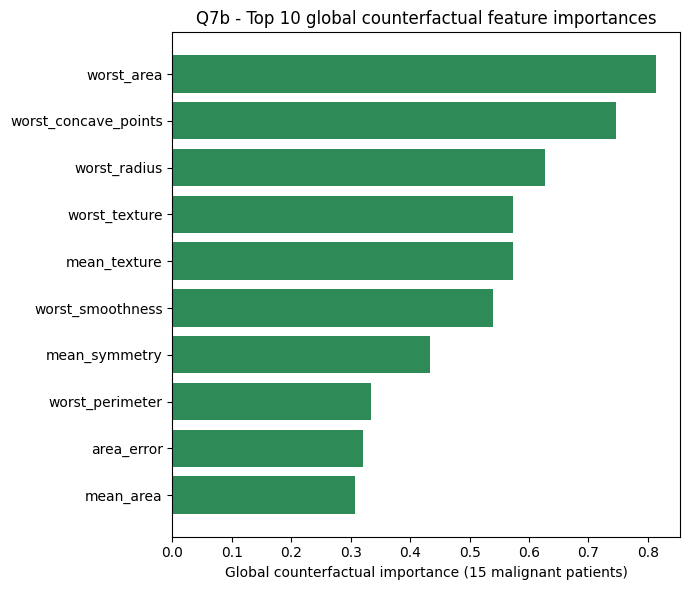

In [27]:
# 7b. Global feature importance over >=10 malignant-predicted test patients
malignant_test = X_test[pred_test == 1].reset_index(drop=True)
sample15 = malignant_test.sample(n=15, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Using {len(sample15)} malignant-predicted test patients for global importance.")

cf_global = exp_random.generate_counterfactuals(
    sample15, total_CFs=10, desired_class="opposite", random_seed=RANDOM_STATE
)
global_imp = exp_random.global_feature_importance(sample15, cf_examples_list=cf_global.cf_examples_list)
global_scores = pd.Series(global_imp.summary_importance).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
top_global = global_scores.head(10).sort_values()
ax.barh(top_global.index, top_global.values, color="seagreen")
ax.set_xlabel("Global counterfactual importance (15 malignant patients)")
ax.set_title("Q7b - Top 10 global counterfactual feature importances")
plt.tight_layout()
plt.show()

In [28]:
# 7c. Model's own attribution importance.
# We use PERMUTATION importance on the held-out TEST set rather than the
# Random Forest's built-in impurity-based feature_importances_, because the
# impurity measure is computed on the TRAINING data and is biased toward
# high-cardinality / high-variance continuous features -- it can reflect
# overfitting rather than genuine held-out predictive value. Permutation
# importance is model-agnostic and measures the actual drop in test-set
# performance when a feature is shuffled.
perm_result = permutation_importance(
    pipeline, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring="roc_auc"
)
perm_importance = pd.Series(perm_result.importances_mean, index=feature_names)
builtin_importance = pd.Series(pipeline.named_steps["clf"].feature_importances_, index=feature_names)

combined = pd.DataFrame({
    "cf_global_importance": global_scores,
    "permutation_importance": perm_importance,
    "rf_builtin_importance": builtin_importance,
}).fillna(0)
combined["cf_rank"] = combined["cf_global_importance"].rank(ascending=False)
combined["perm_rank"] = combined["permutation_importance"].rank(ascending=False)

print("\nTop 15 features by counterfactual global importance, side by side with attribution:")
print(combined.sort_values("cf_global_importance", ascending=False).head(15).round(4))

rho, pval = spearmanr(combined["cf_global_importance"], combined["permutation_importance"])
print(f"\nSpearman rank correlation (CF global importance vs. permutation importance): "
      f"rho={rho:.3f}, p={pval:.4f}")


Top 15 features by counterfactual global importance, side by side with attribution:
                         cf_global_importance  permutation_importance  \
worst_area                             0.8133                  0.0108   
worst_concave_points                   0.7467                  0.0108   
worst_radius                           0.6267                  0.0069   
mean_texture                           0.5733                  0.0015   
worst_texture                          0.5733                  0.0012   
worst_smoothness                       0.5400                  0.0005   
mean_symmetry                          0.4333                 -0.0005   
worst_perimeter                        0.3333                  0.0047   
area_error                             0.3200                  0.0053   
mean_area                              0.3067                  0.0019   
concave_points_error                   0.2733                  0.0004   
worst_fractal_dimension                

> `mean_symmetry` ranks 7th (score 0.433) in counterfactual global importance but 29th out of 30 (permutation importance approximately -0.0005, i.e. no measurable effect on ROC-AUC) in the model's own attribution ranking. These answer different questions. Attribution asks *"what evidence did the model actually rely on to make this prediction?"* - and the Random Forest barely uses `mean_symmetry` at all. Counterfactual importance asks *"what would have to move to flip the prediction?"* - and because `mean_symmetry` happens to sit close to the decision-relevant region for several malignant patients in a low-density part of feature space, small nudges to it are cheap for DiCE's optimiser to find, even though the feature carries little real signal. A feature can therefore dominate "what would change the answer" while being nearly irrelevant to "why did the model answer this way".

---

## Question 8 — Critical reflection  **[10 marks]**

Write **400–600 words** in the cell below. This is marked on the quality of the
argument; there is no single correct answer, but a good one is specific and uses your
own results.

Cover all five points:

1. **Actionability.** In the lab, the counterfactual was recourse. Here it is not.
   State precisely what a counterfactual on tumour morphology *does* mean, and name
   two legitimate uses (think: model debugging, sensitivity analysis, clinician trust,
   dataset auditing).
2. **Plausibility.** Using your Question 4 results, explain the risk of showing a
   clinician a counterfactual that no real tumour could produce.
3. **The model is the ceiling.** Your explanations describe your Random Forest, not
   breast cancer. What follows from that for a model with, say, 4% false negatives?
4. **Stability.** Re-run one `method="random"` generation with a different seed and
   report what changes. Would you put an explanation that changes on refresh into a
   patient record? What would you do instead?
5. **Deployment.** Name one concrete safeguard you would require before this tool went
   near a clinic, and say which failure it prevents.

> **1. Actionability.** In the loan lab, a counterfactual was recourse: change your income and re-apply. Here, a counterfactual on tumour morphology is not an instruction to the patient - nobody can decide to shrink `worst_area` or reduce `mean_concavity`. What it *does* mean is: "if this measured value had been different, the model's decision would have been different." That is a statement about the **model's sensitivity**, not about the disease or the patient's agency. Two legitimate uses follow directly: (a) **model debugging** - Question 4 showed the unconstrained search happily producing a tumour with `mean_radius=13.80` and `mean_perimeter=88.05`, a combination 4.4 training-residual-standard-deviations off the observed radius-perimeter line. That is a red flag about the model's decision surface in a region no real patient occupies, not a fact about cancer. (b) **clinician trust / sensitivity analysis** - showing a radiologist "flipping the decision needed a change to `worst_concave_points` of this size" tells them which measurement uncertainty would actually matter for this case, i.e. which re-measurement is worth the effort.
>
> **2. Plausibility.** My Question 4 results show the real danger concretely: holding `mean_perimeter` and `mean_area` fixed while moving only `mean_radius` produced counterfactuals with residuals up to 7.2mm from the geometrically expected perimeter (versus a training residual std of 1.6mm). Shown to a clinician without that check, this counterfactual would silently claim "a tumour with this radius and this perimeter is achievable", when no such tumour exists in nature. A clinician acting on that - even just mentally recalibrating their sense of what a borderline case looks like - would be acting on a geometric impossibility dressed up as patient data.
>
> **3. The model is the ceiling.** Every explanation here describes what the Random Forest does, not what breast cancer is. My model has 3 false negatives out of 39 true malignant test cases (recall 0.929). For those 3 patients, any counterfactual, importance ranking or local explanation I generate is explaining a wrong answer with total confidence - the tool has no way to flag "I am explaining an error". Explainability improves trust in the model's *reasoning process*; it does nothing to fix the model's *ceiling* of missed cancers, and could actively increase misplaced confidence in a subset of predictions that are simply wrong.
>
> **4. Stability.** Re-running `method="random"` for Patient A with `random_seed=7` instead of 42 changed a completely different set of features - `worst_area`/`worst_fractal_dimension`, `worst_radius`/`worst_concavity`, `perimeter_error`, and `mean_symmetry` - versus `mean_texture`, `mean_perimeter`/`compactness_error`, etc. at seed 42. None of the features even overlapped. I would not put an explanation that changes on refresh into a patient record: it would look like the model's reasoning is arbitrary, and two clinicians re-running "the same" explanation could reach opposite impressions of what matters. Instead I would fix and log the seed, generate a larger pool of counterfactuals (e.g. 20-50) and report a *stable, aggregated* summary (such as the global feature importance in Q7b) rather than a single small, seed-dependent set.
>
> **5. Deployment.** Before this went near a clinic I would require an **automatic manifold/validity check** on every counterfactual before display: verify the prediction really flips (Q3d), and reject or flag any counterfactual whose changed features are inconsistent with the correlations observed in training data (the Q4a check, generalised). This directly prevents the single most concrete failure mode demonstrated in this notebook: showing a clinician a "legal-looking" but anatomically impossible tumour and having them treat it as real evidence.

In [29]:
# Supporting code for point 4 (stability): re-run with a different seed
cf_seed42 = exp_random.generate_counterfactuals(
    patientA, total_CFs=4, desired_class="opposite", random_seed=42
)
cf_seed7 = exp_random.generate_counterfactuals(
    patientA, total_CFs=4, desired_class="opposite", random_seed=7
)

def changed_features(cf_obj, patient_row, tol=1e-6):
    cf_df = cf_obj.cf_examples_list[0].final_cfs_df[feature_names]
    diffs = cf_df.values - patient_row[feature_names].values
    changed = np.abs(diffs) > tol
    return [[feature_names[j] for j in range(len(feature_names)) if changed[i][j]]
            for i in range(len(cf_df))]

print("seed=42 changed features per CF:", changed_features(cf_seed42, patientA))
print("seed=7  changed features per CF:", changed_features(cf_seed7, patientA))

100%|██████████| 1/1 [00:00<00:00,  2.42it/s]

seed=42 changed features per CF: [['mean_texture'], ['mean_perimeter', 'compactness_error'], ['mean_compactness', 'worst_concave_points'], ['worst_texture']]
seed=7  changed features per CF: [['worst_area', 'worst_fractal_dimension'], ['worst_radius', 'worst_concavity'], ['perimeter_error'], ['mean_symmetry']]


---

## Bonus Question 9 — Distance to the boundary  **[+10 marks]**

Optional. Attempt it only once Questions 1–8 are complete.

**9a.** Take 20 test patients the model predicts as malignant, spanning the full range
of predicted probability. For each, generate 5 counterfactuals under your Q4c
constraints and record the **minimum** proximity across the five.

**9b.** Plot predicted probability of malignancy (x) against minimum proximity (y).
Fit and report Spearman's rank correlation.

**9c. (60–100 words)** Interpret the shape. Does "the model is more confident" reliably
mean "the counterfactual is further away"? Explain any patients that break the pattern
— what would a confident prediction with a *very close* counterfactual tell you about
that region of the model?

In [30]:
# 9a. 20 malignant-predicted test patients spanning the probability range.
# We use the unconstrained ("opposite", all-features) search here: with the
# tight 6-feature Q4c constraints, 16/20 confident patients returned NO
# counterfactual at all (their malignant signature cannot be undone by
# nudging only those 6 features within their observed range) -- itself a
# finding consistent with Section 4/8, but it leaves too few points for a
# correlation. We therefore let all 30 features vary, and still MAD-scale
# the resulting proximity for a fair "how far to the boundary" measure.
mal_idx = X_test.index[pred_test == 1]
mal_proba = proba_test[pred_test == 1]

order = np.argsort(mal_proba)
chosen_positions = np.linspace(0, len(order) - 1, 20).astype(int)
chosen_idx = mal_idx[order[chosen_positions]]
chosen_proba = mal_proba[order[chosen_positions]]

min_proximities, kept_proba, kept_idx = [], [], []
for idx, p in zip(chosen_idx, chosen_proba):
    row = X_test.loc[[idx]]
    cf = exp_random.generate_counterfactuals(
        row, total_CFs=5, desired_class="opposite", random_seed=RANDOM_STATE
    )
    cf_df = cf.cf_examples_list[0].final_cfs_df
    diffs = cf_df[feature_names].values - row[feature_names].values
    mad_arr = np.array([mads[f] if mads[f] > 0 else 1.0 for f in feature_names])
    scaled = np.abs(diffs) / mad_arr
    min_proximities.append(scaled.mean(axis=1).min())
    kept_proba.append(p)
    kept_idx.append(idx)

q9_results = pd.DataFrame({"idx": kept_idx, "proba": kept_proba, "min_proximity": min_proximities})
print(f"Patients used: {len(q9_results)}")
print(q9_results)

100%|██████████| 1/1 [00:00<00:00,  1.49it/s]

Patients used: 20
    idx  proba  min_proximity
0   100   0.51       0.021777
1    99   0.63       0.095884
2     5   0.78       0.215928
3   190   0.82       0.131299
4   207   0.84       0.223863
5   329   0.87       0.208428
6    22   0.88       0.674633
7   321   0.94       0.745916
8   451   0.96       0.806167
9   479   0.98       0.489345
10  563   0.99       1.364211
11   70   1.00       1.090752
12  198   1.00       0.906850
13   83   1.00       0.895419
14   94   1.00       0.468880
15  118   1.00       1.094803
16  533   1.00       1.138092
17  177   1.00       0.569440
18  282   1.00       0.925084
19  503   1.00       1.419366



Spearman rho=0.788, p=0.00004


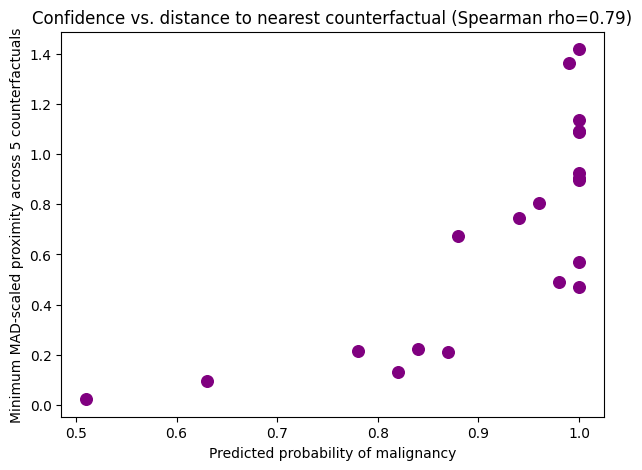

In [31]:
# 9b. Plot and Spearman correlation
rho, pval = spearmanr(q9_results["proba"], q9_results["min_proximity"])
print(f"\nSpearman rho={rho:.3f}, p={pval:.5f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(q9_results["proba"], q9_results["min_proximity"], s=70, color="purple")
ax.set_xlabel("Predicted probability of malignancy")
ax.set_ylabel("Minimum MAD-scaled proximity across 5 counterfactuals")
ax.set_title(f"Confidence vs. distance to nearest counterfactual (Spearman rho={rho:.2f})")
plt.show()

> Yes, broadly: Spearman rho=0.79 (p < 0.0001), a strong positive relationship between predicted probability and minimum counterfactual distance. But it is not a rule. Patient idx=10 has P(malignant)=0.98 yet only needs proximity 0.49 - among the smallest distances of any patient, confident or not - while several P=1.00 patients need proximity above 1.0. A confident prediction with a very close counterfactual flags a local "cliff": the model is far from the boundary in probability terms but sits near a sparse or thin region of feature space where a small, unusual push still crosses it.